In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../database/drug_discovery.db")
plants = pd.read_sql("SELECT * FROM plants", conn)
plants.head()

,plant_id,species_name,genus,family,traditional_use,selection_score,voucher_number
0,1,Centella asiatica,Centella,Apiaceae,None,5,PRU 124298
1,2,Heteromorpha arborescens,Heteromorpha,Apiaceae,None,7,PRU 124318
2,3,Mondia whitei,Mondia,Apocynaceae,None,4,PRU 124299
3,4,Stapelia gigantea,Stapelia,Apocynaceae,None,9,PRU 124308
4,5,Tabernaemontana elegans,Tabernaemontana,Apocynaceae,None,8,PRU 124300


Matplotlib is building the font cache; this may take a moment.


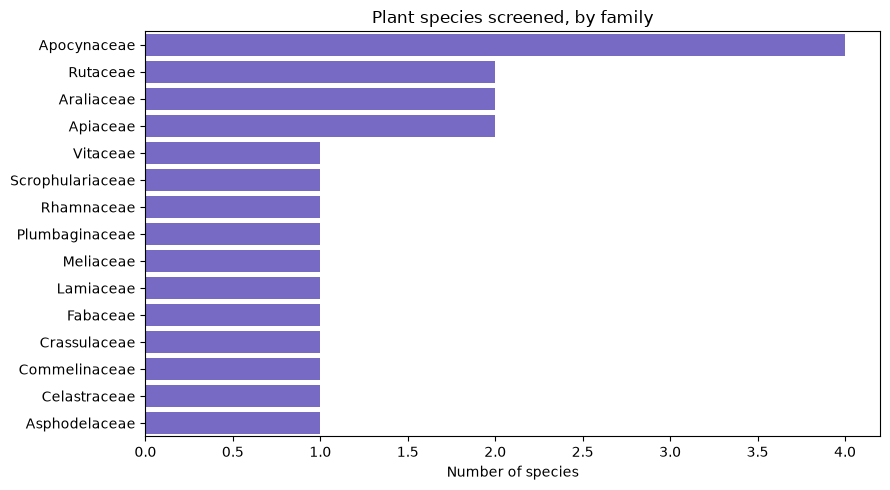

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fam = pd.read_sql("""
    SELECT family, COUNT(*) AS n
    FROM plants
    GROUP BY family
    ORDER BY n DESC
""", conn)

plt.figure(figsize=(9,5))
sns.barplot(data=fam, x="n", y="family", color="#6b5bd4")
plt.xlabel("Number of species")
plt.ylabel("")
plt.title("Plant species screened, by family")
plt.tight_layout()
plt.show()

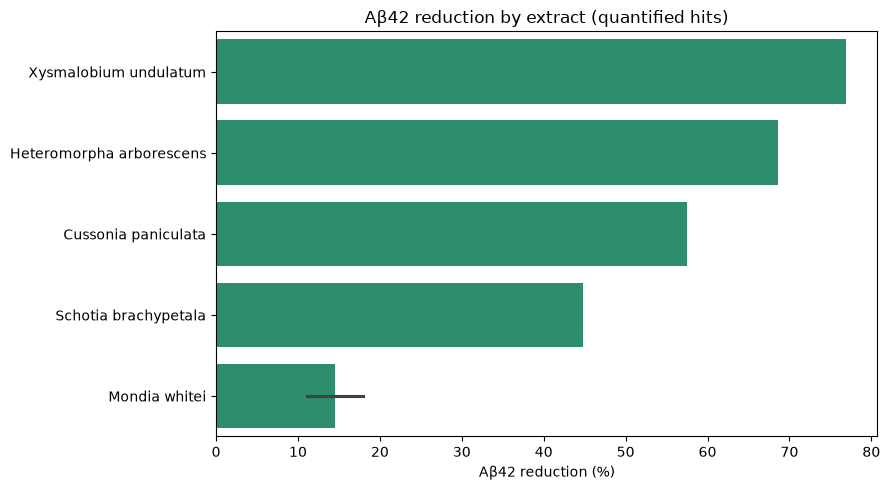

In [3]:
hits = pd.read_sql("""
    SELECT p.species_name, ar.result_pct
    FROM assay_results ar
    JOIN extracts e ON ar.extract_id = e.extract_id
    JOIN plants p   ON e.plant_id = p.plant_id
    WHERE ar.result_pct IS NOT NULL
    ORDER BY ar.result_pct DESC
""", conn)

plt.figure(figsize=(9,5))
sns.barplot(data=hits, x="result_pct", y="species_name", color="#1d9e75")
plt.xlabel("Aβ42 reduction (%)")
plt.ylabel("")
plt.title("Aβ42 reduction by extract (quantified hits)")
plt.tight_layout()
plt.show()

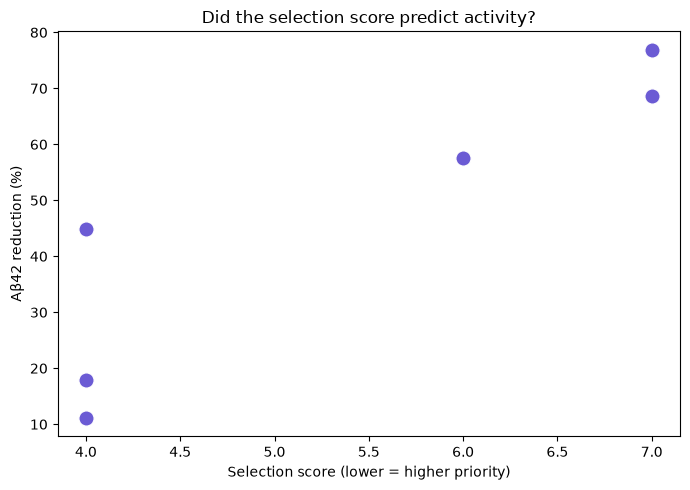

In [4]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=pd.read_sql("""
    SELECT p.species_name, p.selection_score, ar.result_pct
    FROM assay_results ar
    JOIN extracts e ON ar.extract_id = e.extract_id
    JOIN plants p   ON e.plant_id = p.plant_id
    WHERE ar.result_pct IS NOT NULL
""", conn), x="selection_score", y="result_pct", s=120, color="#6b5bd4")
plt.xlabel("Selection score (lower = higher priority)")
plt.ylabel("Aβ42 reduction (%)")
plt.title("Did the selection score predict activity?")
plt.tight_layout()
plt.show()

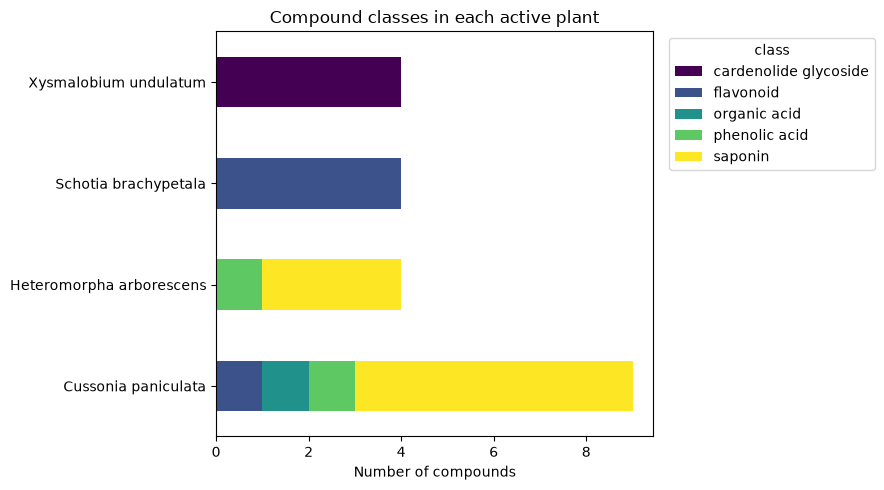

In [5]:
comp = pd.read_sql("""
    SELECT p.species_name, c.molecular_class, COUNT(*) AS n
    FROM compounds c
    JOIN sample_compounds sc ON c.compound_id = sc.compound_id
    JOIN extracts e ON sc.extract_id = e.extract_id
    JOIN plants p   ON e.plant_id = p.plant_id
    GROUP BY p.species_name, c.molecular_class
""", conn)

pivot = comp.pivot_table(index="species_name", columns="molecular_class", values="n", fill_value=0)
pivot.plot(kind="barh", stacked=True, figsize=(9,5), colormap="viridis")
plt.xlabel("Number of compounds")
plt.ylabel("")
plt.title("Compound classes in each active plant")
plt.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Exploratory Analysis: Medicinal Plants for Alzheimer's

Screening 21 South African medicinal plants for reduction of Aβ42, the peptide
implicated in Alzheimer's disease. Data from A. Thakur, PhD thesis (University of
Pretoria), rebuilt as a relational SQLite database and analysed here with pandas.

**Questions:**
1. Which plant families were screened, and how thoroughly?
2. Which extracts actually reduced Aβ42?
3. Did the prior-knowledge selection score predict activity?
4. What chemistry drives the active extracts?

## 1. What was screened

21 species across 15 families. Apocynaceae is the most represented — unsurprising,
as it's a family known for bioactive cardenolides.

## 2. Which extracts reduced Aβ42

Of 34 extracts screened at 50 µg/mL, 11 significantly reduced Aβ42 (a 32% hit rate).
Four were potent enough (≥44%) to carry forward for chemical profiling. *Xysmalobium
undulatum* was the strongest at 76.9%.

## 3. Did the selection score predict activity?

Plants were prioritised by a score built from traditional use and prior literature
(**lower = higher priority**). If it worked, low scores should show high activity —
points trending down-and-right. They don't. The two most active plants scored 7
(mid-priority), while a top-priority plant (score 4) was among the weakest. A score
built on *prior* knowledge structurally can't surface *novel* actives, because novel
means undocumented. *(Note: 6 data points — suggestive, not statistically fitted.)*

## 4. What chemistry drives the actives

Each active plant has a distinct chemical fingerprint: *X. undulatum* is pure
cardenolide glycoside, *S. brachypetala* pure flavonoid, *C. paniculata* a diverse
saponin-rich mix. There's no single shared active class — multiple structural routes
to the same effect. The *X. undulatum* cardenolides are the key lead: active at
nanomolar levels, though the lactone ring that drives activity also drives cardiotoxicity.